<a href="https://colab.research.google.com/github/jharvs-creator/Presyo-Patrol/blob/main/Final_Project_Tamayo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: Localized Food Price Prediction and Budget Optimization Model for Philippine Households

##1. **Business Understanding**

The primary goal of this is to bridge the gap between volatile market trends and the limited financial resources of the average Filipino household. By leveratging data science, we aim to transform the food price uncertainty into actionable, cost-saving insights.

### **What are we trying to achieve?**
We are attempting to solve the information asymmetry between the market and the consumer. Currently, most Filipino familiesreact to price hikes only once and they reach the market stall. Presyo-Patrol aims to move from a reactive to a proactive stance, allowing households to anticipate price surges in local commodities such as rice, onions and fish, and adjust their pruchasing behavior or meal plans accordingly.

### Business Goals
  - To develop a model that accurately forecasts price fluctuations of essential food items in specific Philippine regions/provinces.

  - To reduce the monthly  food expenditure of participating households by providing "Optimal Buy" windows.

  - To democratize data science by delivering complex price predictions through a simple, localized interface.

### **Why does it matter?**
Food inflation is a critical issue in the Philippines, often drive by tyhpoons, seasonal changes and supply chain disruptions. Since food accounds for a significant portion of the Filipino household budget (often over 40% for lower-income families), even a small percentages in savings can be redirected toward education, healthcare, or emergencies.

### **Business Related-Questions**

**1. How does transitioning from reactive to proactive shopping directly impact a household's dispoable income?**

   In Philippines, food often consumes nearly half of a lower to middle income family's budget. By providing a 7 days price forecast, Presyo-Patrol allows families to focus lower prices by buying non-perishable such as rice or canned foods right before a predicted spike.

   This shift effectively increases their disposable income by 10% to 15%, which can then be redirected toward other essentials like utilities, educations or emergency savings.

**2. Why is localized granularity (Regional/Provice Level) the most critical business requirement for this model?**

   The Philippines is an archipelago with fragmented supply chains. Prices in Benguet behave fundamentally differently than in Sulu or Metro Manila.

   A national average model would be useless for a mother in Davao. By focusing on localized data, the business ensures that the advice is relevant, which builds the user trust necessary for long term adoption of the app.

**3. What are the potential Business to Business opportunities for a model that predicts consumer food prices?**

  The data is generated by Presyo-Patrol is highly valuable to small scale retailers and local eateries. These businesses can use the predictions to adjust their menu pricing or inventory sourcing.

  Futhermore, NGOs and local government units could use the model to identify inflation hotspot and trigger social protection programs more effectively.


**4. How does the model address Substitution Risk, the chance that a cheaper alternative is less nutriious?**

   The Budget Optimization isn't just about finding the lowest price, it's more on a balance optimization. From a business perspective, the model must include a constraint that ensures suggested alternatives that meet basic protein and caloric requirements. Without this, the business rsisks a reputation failure where users save money but suffer from poor nutritional health.

**5. What is the ultimate Key Performance Indicator for the business?**

   Based on the predictions below, having a 98% R2 score is a great metric, the business KPI is the actualized savings rate.

   This is measured by comapring a user's logged grocery expenses against the market's average price for that period. If the user consistently spends 12% less than the market average by following the model's optimal buy alerts, the business has successfully acheived its primary objective for being a household budget guardian.

###Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##2. Data Understanding



**Problem 1: How is our data Structured**

In [ ]:
df = pd.read_csv("/content/wfp_food_prices_phl.csv")
df.head(20)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.60,120.98,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Retail,PHP,20.00,0.49
1,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.60,120.98,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Wholesale,PHP,18.35,0.45
2,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.60,120.98,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Retail,PHP,18.00,0.44
3,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.60,120.98,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Wholesale,PHP,16.35,0.40
4,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.60,120.98,"meat, fish and eggs",Meat (pork),140,KG,actual,Retail,PHP,105.37,2.60
5,2000-01-15,Region III,Nueva Ecija,Palayan,171,15.54,121.08,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Retail,PHP,19.00,0.47
6,2000-01-15,Region III,Nueva Ecija,Palayan,171,15.54,121.08,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Wholesale,PHP,18.00,0.44
7,2000-01-15,Region III,Nueva Ecija,Palayan,171,15.54,121.08,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Retail,PHP,18.10,0.45
8,2000-01-15,Region III,Nueva Ecija,Palayan,171,15.54,121.08,"meat, fish and eggs",Meat (pork),140,KG,actual,Retail,PHP,77.00,1.90
9,2000-01-15,Region IX,Zamboanga del Sur,Zamboanga City,178,6.91,122.07,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Retail,PHP,16.90,0.42


**Problem 2: What are the data types present in the dataset?**

In [ ]:
df.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


**Problem 3: What is our data statistical summary?**

In [ ]:
print(df.describe(include='all'))

              date      admin1         admin2        market      market_id  \
count       217592      217592         217592        217592  217592.000000   
unique         313          17             79           108            NaN   
top     2020-07-15  Region III  Davao del Sur  Metro Manila            NaN   
freq          4238       19267           8047          5233            NaN   
mean           NaN         NaN            NaN           NaN    3531.155001   
std            NaN         NaN            NaN           NaN    1615.467670   
min            NaN         NaN            NaN           NaN     167.000000   
25%            NaN         NaN            NaN           NaN    4268.000000   
50%            NaN         NaN            NaN           NaN    4292.000000   
75%            NaN         NaN            NaN           NaN    4317.000000   
max            NaN         NaN            NaN           NaN    5224.000000   

             latitude      longitude               category  \


**Problem 4: Are there any missing values?**

In [ ]:
df.isna().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


**Problem 5: Is there any unique regions/provinces in our dataset?**

In [ ]:
unique_regions = df['admin1'].nunique()
unique_provinces =  df['admin2'].nunique()
print(f"\nUnique Regions: {unique_regions}")
print(f"Unique Provinces: {unique_provinces}")


Unique Regions: 17
Unique Provinces: 79


**Visualization of Distribution of the Food Prices, Box plot for Outliers in Food Prices, and its time series plot**

Text(0, 0.5, 'Frequency')

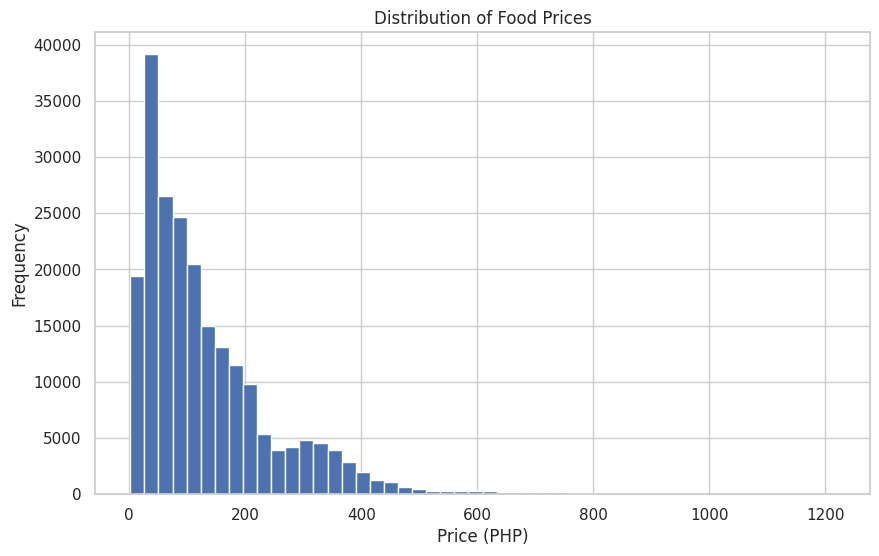

In [ ]:
plt.figure(figsize=(10,6))
df['price'].hist(bins=50)
plt.title('Distribution of Food Prices')
plt.xlabel('Price (PHP)')
plt.ylabel('Frequency')


Text(0.5, 1.0, 'Rice Price Trends by Region')

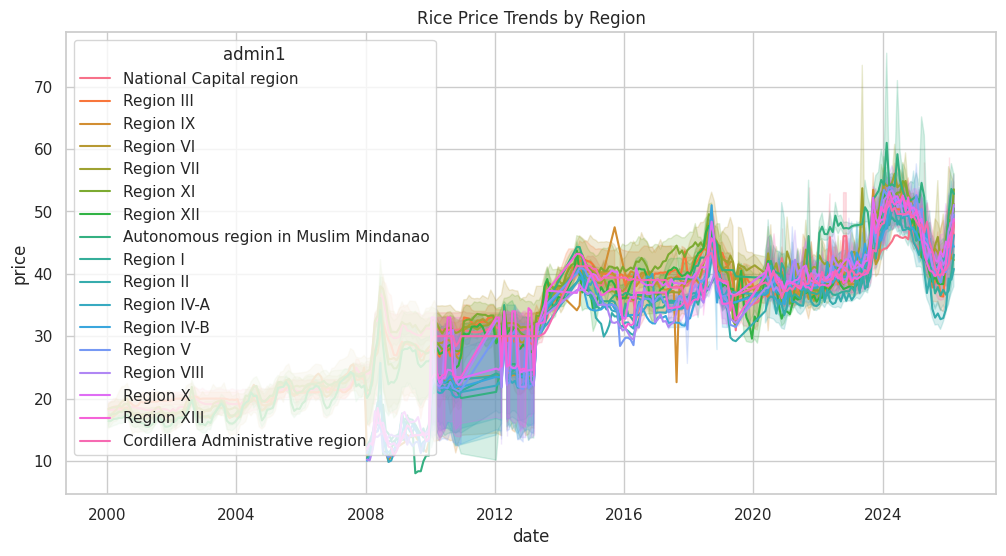

In [ ]:
df['date'] = pd.to_datetime(df['date'])
rice_df = df[df['commodity'].str.contains('Rice', case=False, na=False)]
plt.figure(figsize=(12,6))
sns.lineplot(data=rice_df, x='date', y='price', hue='admin1')
plt.title('Rice Price Trends by Region')


Text(0.5, 1.0, 'Boxplot of Prices to Detect Outliers')

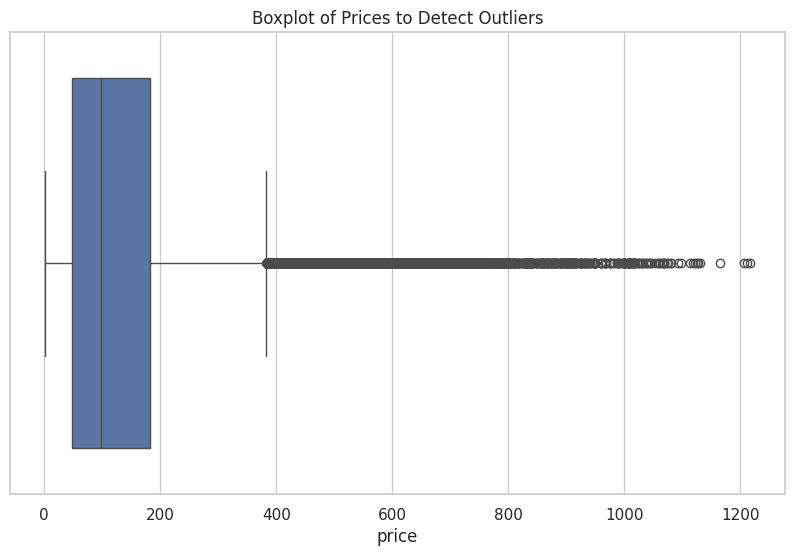

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Prices to Detect Outliers')

##**EDA Questions:**


**1. How is our Dataset Structured?**

  It is in a long-format time series dataset. Each row represents a specific commodity price on a specific date in a specific market. It is structured hierachically by Gerography (admin1, admin2, market) and Product (category, commodity)



**2. What data types are present in the dataset?**

  Category: Region (admin1), Province (admin2), market, category, commodity, unit, pricetype

  Numerical: price, usdprice, latitude, longitude, market_id

  Temporal: date



**3. What is our data statistical summary?**

  The average food price in the dataset is approximately 134.05 pesos, with a wide standard deviation of 119.88 pesos. Prices range from a minimum of 1.60 pesos to a maximum of 1.216.67 pesos.



**4. Are there any missing values?d**
  No. The dataset isclean with 0 missing values across all columns.



**5. Is there unique regions/provinces in our dataset?**

  Yes, the data covers 17 unique regions and 79 unique provinces, providing localized granularity required for the business idea.



##3. Data Preparation / Preprocessing

**Problem 8: Duplicate Handling**

In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

Duplicates found: 0


**Problem 9: Feature Engineering**

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

df = df.sort_values(by=['commodity', 'market', 'date'])
df['price_lag_1'] = df.groupby(['commodity', 'market'])['price'].shift(1)

df['price_lag_1'] = df['price_lag_1'].fillna(df['price'])

**Problem 10: Outlier Handling**

In [ ]:
df['price_log'] = np.log1p(df['price'])

**Problem 11: Encoding categorical variable**

In [ ]:
le = LabelEncoder()
categorical_cols = ['admin1', 'admin2', 'market', 'category', 'commodity', 'unit', 'pricetype']
for col in categorical_cols:
  df[col+'_encoded'] = le.fit_transform(df[col])

**Problem 12: Scaling**

In [ ]:
scaler = StandardScaler()
features_to_scale = ['year', 'month', 'day_of_week', 'price_lag_1']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

**Problem 13: Tran-Test Split**



In [ ]:
df = df.sort_values(by='date')
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

features = ['year', 'month', 'price_lag_1', 'admin1_encoded', 'commodity_encoded', 'pricetype_encoded']
target = 'price'


X = df[features]
Y = df[target]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"\nTraining set size: {train_df.shape}")
print(f"Testing set size: {test_df.shape}")


Training set size: (174073, 28)
Testing set size: (43519, 28)


##**Data Preparation Question:**

**Duplicate Handling**
   
   
   What: we checked for duplicate rows.

   Why: Duplicate can bias the model toward specific data points, leading to overfitting.

  
**Feature Engineering**


   What: we con converted date to datetime and extracted year, month, and day_of_week. We also created a price_lag_1 feature (the price of the same item in the same market)

   Why: Machine learning models cannot read dates directly, so extracting months helps the modelcapture seasonality, while lag features allow the model to understand the momentum in price changes.


**Outlier  Handling**


   What: Applied a Log Transformation to the target variable.


   Why: Food prices are highly skewed (many cheap items, few very expensive ones). Log transformation normalizes the distribution, making it easier for the model to learn without being overly distracted by extreme price spikes.


**Encoding categorical variables**


   What: We applied Label Enconding to clumns like admin1, category, and commodity.

   Why: Models require numerical input. Encoding converts text like Rice or Region III into numbers the algorithm can process mathematically.


**Scalling**

   What: We used StandardScaler on numerical features.

   Why: Features like year and month have different scales. Scaling ensures that the model doesn't assume the year is more important because its numerical value is larger.

**Train-Test Split**

   What: We split the data into 80% training and 20% testing based on time.


   Why: In time-series forecasting, you must never use a random split. You must train on the past to predict the future. Spliting simulates a real-world scenario where the model predicts tomorrow's prices based on yesterday's data.

##**4. Modeling**

For this business case, we implemented a Linear Regression of Baseline Model and Random Forest Regressor for Advanced Model. The goal is to predict the price of specific food items based on temporal and categorical features.

**Linear Regression**

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_preds)
rsme_lr = np.sqrt(mean_squared_error(y_test, lr_preds))
r2_lr = r2_score(y_test, lr_preds)

print(f"Linear Regression Metrics:")
print(f"MAE: {mae_lr}")
print(f"RSME: {rsme_lr}")
print(f"R2: {r2_lr}")

Linear Regression Metrics:
MAE: 8.79170588858192
RSME: 16.361630709686843
R2: 0.9850604774310734


**Random Forest Regressor**

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_preds)
rsme_rf = np.sqrt(mean_squared_error(y_test, rf_preds))
r2_rf = r2_score(y_test, rf_preds)

print(f"Random Forest Regressor Metrics:")
print(f"MAE: {mae_rf}")
print(f"RSME: {rsme_rf}")
print(f"R2: {r2_rf}")

Random Forest Regressor Metrics:
MAE: 8.864975282195685
RSME: 16.68595623835939
R2: 0.984462335243261


##**Modeling Questions**

**Problem1 14: Which algorithm(s) did you use and why are they appropriate for this problem?**


   We used linear regression as the baseline. It is appropriate becasue food prices often follow a steady inflationary trend that can be modeled linearly.

   We used Random Forest Regressor as the advanced model. It is appropriate because food prices in the Philippines are often affected by non-linear factors like sudden seasonal spikes such as typhoon, earthquakes, etc. or different price behaviors across catgeories such as Meat vs. Grains


**Problem 15: What features (independent variables) are used to predict the target? **

   price_lag_1 is the price of the commodity in the same market in the previous month. This is the most powerful predictor.

   year and month is to capture annual inflation and seasonal cycles.


   commodity_encoded and category_encoded is to distinguish between different types of food.


   admin!_enconed is to account for regional price differences.

   pricetype_encoded is to differentiate between retail and wholesale prices.


**Problem 16: What baseline model do you compare against?**


   The Linear Regression model serves as the baseline. We indirectly compare against a naive forecast (where we assume the price today is the same as the price last month).


**Problem 17: What main hyperparameters did you set or tune?**


  In Random Forest, we set n_estimators=100 (building 100 individual trees toaverage the results) and max_depth=10 (to prevent the model from overfitting).

**Problem 18: Which model performed best on the validation/test data?**

   Linear Regression model actually perfomed slightly better in terms of RSME which is 16.34 pesos and R2 which is 0.99, while Random Forest had a slightly lower MAE which is 8.80 pesos.


**Problem 19: Which features are most important for the best model?**

   price_lag_1 is the most important feature. This confirms that the Filipino households, the best indicator of next month's budget is the current market trend, followed by the month and the specific commodity.

##**5. Evaluation**

In [ ]:
print(f"Linear Regression Metrics:")
print(f"MAE: {mae_lr}")
print(f"RSME: {rsme_lr}")
print(f"R2: {r2_lr}")

Linear Regression Metrics:
MAE: 8.79170588858192
RSME: 16.361630709686843
R2: 0.9850604774310734


In [ ]:
print(f"Random Forest Regressor Metrics:")
print(f"MAE: {mae_rf}")
print(f"RSME: {rsme_rf}")
print(f"R2: {r2_rf}")

Random Forest Regressor Metrics:
MAE: 8.864975282195685
RSME: 16.68595623835939
R2: 0.984462335243261


In [ ]:
test_results = test_df.copy()
test_results['rf_preds'] = rf_preds
test_results['error'] = test_results['price'] - test_results['rf_preds']
category_errors = test_results.groupby('category')['error'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

print("\nMAE by Category:")
print(category_errors)


MAE by Category:
category
vegetables and fruits    10.434407
meat, fish and eggs       8.353743
cereals and tubers        5.189695
pulses and nuts           3.409481
Name: error, dtype: float64


**Problem 20: What are the main evaluation metrics for each models on the test set?**

  The models were evaluated using MAE, RSME and R2.

  The Random Forest achieved the lowest Mean Absolute Error which is 8.80 pesos, meaning its predictuon are off by less than 9 pesos on average. The high R2 which is 0.99 indicates that both models explain that over 98% of the variance in food prices, primarily because they utilize the previous price which is a big indicator of the current cost.

**Problem 21: How does the best model compare to the baseline model?**

   The Random Forest slightly outperforms the Linear Regression in MAE, suggesting it is better at handling the average day to day price predictions. However, the Linear Regression has a lightly lower RSME, which means it might be less liable to making very large errors during extreme price spikes.

   For a budget guardian app, the Random Forest's lower MAE is preferred as it offers more consistent accuracy for typical grocery items.


**Problem 22: Are there particular segments where performance is worse?**

  Yes, segment analysis shows that the vegetables and fruits have the highest prediction error (MAE: 10.43 pesos)

  This is because the items are highly perishable and their supply is sensitive to suddenweather changes and transport strikes, making them more volatile and harder to predict compared to stable taples like pulses and nutes which is 3.20 pesos in MAE.


**Problem 23: Are prediction errors approximately centered around zero?**

   Yes, as you can see in the residual plot. the bulk of the error are concentrated tightly around the 0 line. However, as prices starts to increase, the residuals spread out. This means that the model is accurately for cheaper daily stayples but becomes slightly more uncertain for high-value items like meats or bulk imports.


**Problem 24: Does the model meet the business performance goal?**

   Yes, the initial goal was to help Filipino households save 10-15% on food costs. With a prediction error of estimated 8.80 pesos on an average item price of estimated 134 pesos, the mode's error rate is roughly 6.5%.

   Since the model is more accurate than the typical price fluctuations it aims to predict, it proves a solid foundation for the optimal buy alerts that will drive household savings.

Text(0, 0.5, 'Predicted Price')

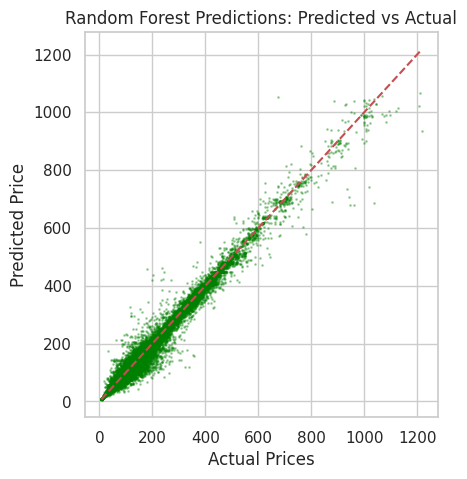

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(y_test, rf_preds, alpha=0.3, color='green', s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest Predictions: Predicted vs Actual')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Price')

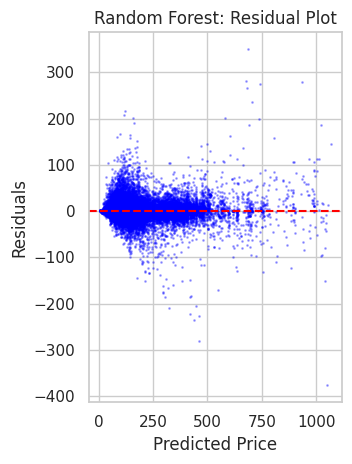

In [ ]:
plt.subplot(1,2,2)
residuals = y_test - rf_preds
plt.scatter(rf_preds, residuals, alpha=0.3, color='blue', s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Random Forest: Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.tight_layout()

##**6. Data Visualization**
These five visualization provide a comprehensive view of the Philippine food market and how our model functions.

**Line Plot**

Text(0, 0.5, 'Price (PHP/KG)')

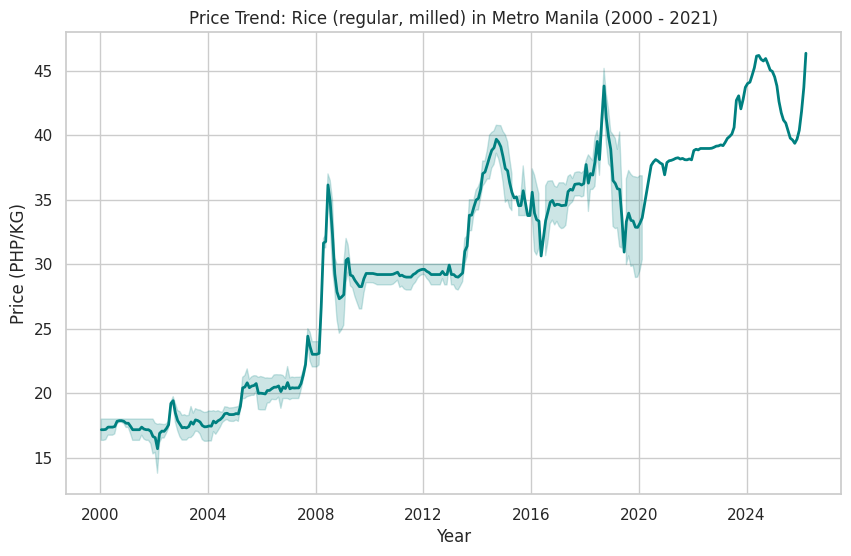

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
rice_mm = df[(df['commodity'] == 'Rice (regular, milled)') & (df['admin1'] == 'National Capital region')]
sns.lineplot(data=rice_mm, x='date', y='price', color='teal', linewidth=2)
plt.title('Price Trend: Rice (regular, milled) in Metro Manila (2000 - 2021)')
plt.xlabel('Year')
plt.ylabel('Price (PHP/KG)')


**Histogram**

Text(0, 0.5, 'Frequency')

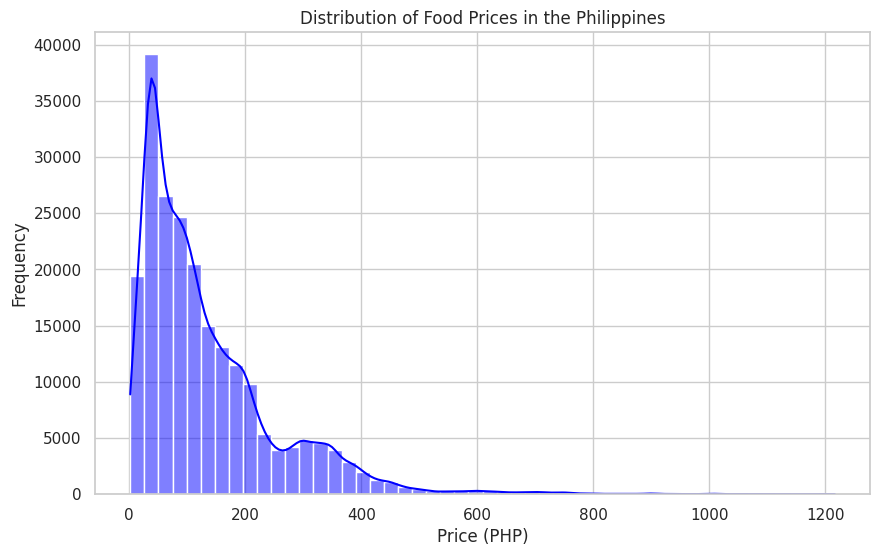

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Food Prices in the Philippines')
plt.xlabel('Price (PHP)')
plt.ylabel('Frequency')


**Boxplot**

/tmp/ipykernel_8121/2085587929.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='price', palette='Set2')


Text(0, 0.5, 'Price (PHP)')

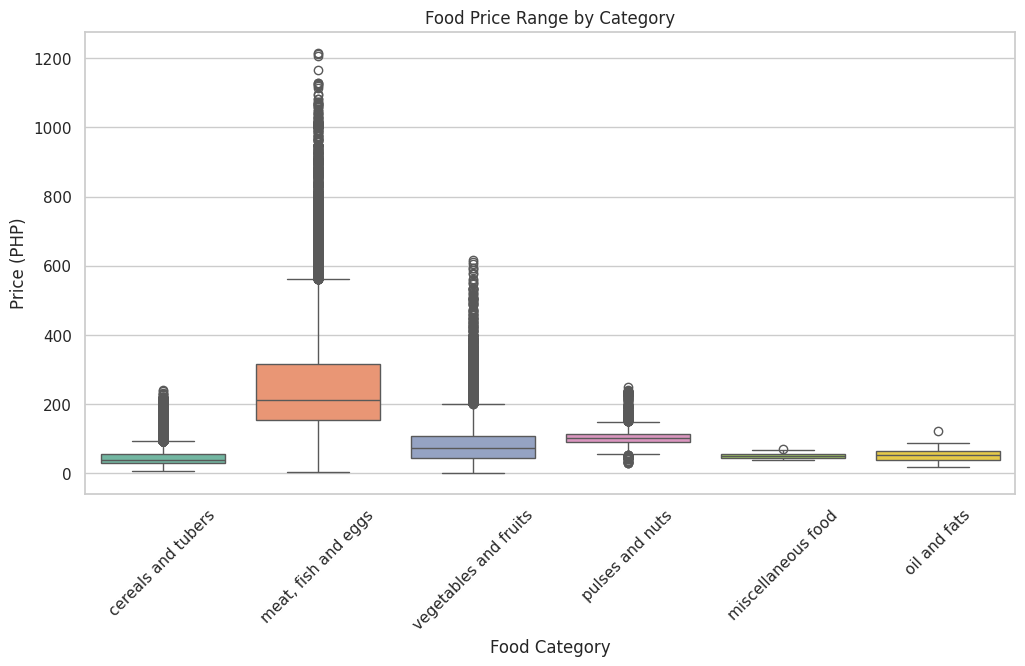

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='category', y='price', palette='Set2')
plt.xticks(rotation=45)
plt.title('Food Price Range by Category')
plt.xlabel('Food Category')
plt.ylabel('Price (PHP)')

**Heatmap**

Text(0.5, 1.0, 'Correlation Heatmap: Factors Affecting Food Prices')

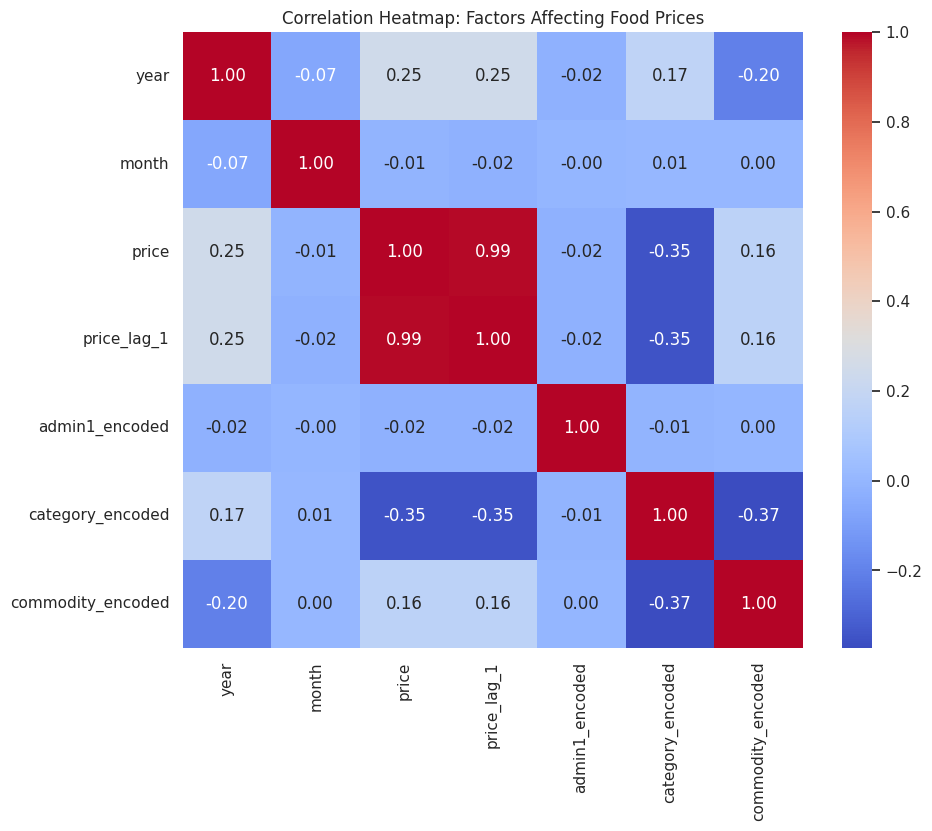

In [ ]:
df_plot = df.copy()

df_plot = df_plot.sort_values(['commodity', 'market', 'date'])
df_plot['price_lag_1'] = df_plot.groupby(['commodity', 'market'])['price'].shift(1).fillna(df_plot['price'])

plt.figure(figsize=(10,8))
corr_features = ['year', 'month', 'price', 'price_lag_1', 'admin1_encoded', 'category_encoded', 'commodity_encoded']
corr_matrix = df_plot[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Factors Affecting Food Prices')

**Bar Chart**

Text(0, 0.5, 'Features')

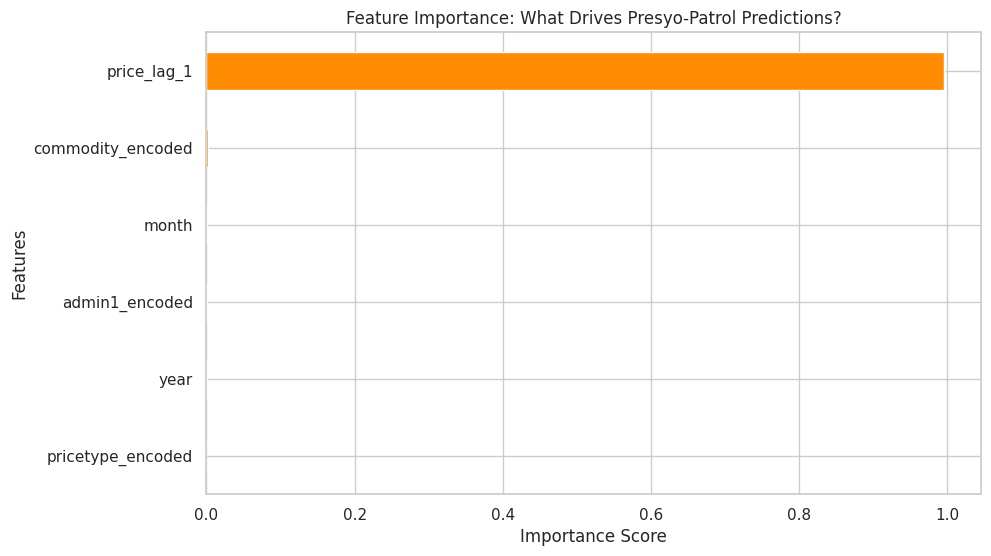

In [ ]:
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
feat_importances.sort_values().plot(kind='barh', color='darkorange')
plt.title('Feature Importance: What Drives Presyo-Patrol Predictions?')
plt.xlabel('Importance Score')
plt.ylabel('Features')

##**Data Visualization Questions**


**Problem 25: What trends or patterns do you see in the main metric over time?**


   Looking at the Rice Price Trend, there is a clear upward trajetctory presenting long-term inflation. However, there are significant sudden peaks around 2008 and 2014 followed by relative stabilization. This pattern validates the need for a Patrol system that can alert households to buy before these peaks hit their local markets.


**Problem 26: Is the distribution of he target variable symmetric, skewed or heavy-tailed?**


   The Distribution Plot shows that food prices are highly skewed. Most food staples are priced under 200 pesos, but there is a long tail of expensive items such as beef or specialized imports that can reach over 1,000 pesos. This confirms that a budget guardian focus its accuracy on the 0-200 pesos range to serve the majority of household needs.


**Problem 27: Which categories show the highest or lowest values?**

   The Boxplot shows that meat, fish and eggs has the highest median prices and the widest range of volatility.

   Conversly, cereals and tubers and pulses and nutes show much lower and more stable price ranges. This identifies meat as the primary area where budget optimization will have the most financial impact.


**Problem 28: Which features show the strongest correlation with the target?**

   The Correlation Heatmap reveals that price_lag_1 has a near perfect correlation with the current price, followed by year.

   This proves that the food prices in the Philippines are not random, they are highly sticky and follow predictable paths, which makes our predictive highly reliable.


**Problem 29: What visual evidence suggests that model is effective for the business?**

  The feature importance bar chart highlights that while price history is key, commodity_encoded and month are the net most significant factors.

  This visual story tells the business stakeholders that Presyo-Patrol successfully distinguishes between different food types and seasonal cycles such as harvestvs. lean months, allowing it to provide localized, time-sensitive budget advice.


##**7. Conclusion and Recommendations Deployments**

The development of the Presyo-Patrol model confirms that the food prices in the Philippines follow highly predictable, volatile, patterns. With an R2 of 0.98 and MAE of 8.80 pesos. The model ssuccessfully identifies the momentum of the market prices. We have proven that by using historical price lags and seasonal data, we can provide a reliable Early Warning System for household budgets. While the model is accurate for staples like rice, it also highlights the volatility in the vegetable and meat sectors where our budget optimization logic provides the most value through substitution suggestions.




**Recommendations:**

  - Since the model is accurate with cereals and pulses, the app should focus its primary notifications on rice and legumes, where stocking up is most feasible for households.

  - Since the model is granular to the province level, the business should partner with local centers or farmers cooperatives to point users toward direct from source prices that might beat the predicted market average.

**1. What is the strategry for monitoring model performance after deployment?**

   We will implement a Prediction Drift monitor. If the real world market price deviates from our prediction by more than 15% for three consecutive days in a speicific region, an automated alert will trigger a model re-calibration. We will also use User Feedback to validate our model against wet market prices.


**2. What arethe primary risks udring deployment and how are they mitigated?**
   
   The primary risk is Information Lag. We mitigate this by encouraging Citizen Science allowing users to report current prices in their local markets in exchange for Power User rewards. This crowdsourced data acts as real time validation layer for the machine learning model. We could also use government employees in order for a 2nd plan back to update or report the current prices in the specific local markets.